# Delivery Time Prediction - Phase 12: Hyperparameter Tuning

## Executive Overview
Welcome to **Phase 12: Hyperparameter Tuning** of the Delivery Time Prediction machine learning project.

In **Phase 10** (Model Comparison) and **Phase 11** (Cross-Validation), we observed that tree-based algorithms (Decision Tree and Random Forest) exhibited noticeable overfitting when trained with unconstrained default parameters (`max_depth=None`, `min_samples_split=2`). In contrast, **Linear Regression** delivered superior out-of-sample generalization.

In this phase, we explore whether **regularizing and tuning** the most suitable flexible candidate models using cross-validated grid search can rein in overfitting, enhance predictive precision, and potentially challenge Linear Regression.

### Phase 12 Objectives
1. **Targeted Candidate Selection**: Focus hyperparameter tuning strictly on the models that possess structural capacity to benefit from regularization:
   * **Random Forest Regressor** (Ensemble candidate with moderate overfitting).
   * **Decision Tree Regressor** (Pruning candidate with severe unpruned memorization).
   * Benchmarked against our untuned **Linear Regression** leader.
2. **GridSearchCV on Training Data Only**: Employ 5-Fold Cross-Validation on `(X_train, y_train)` to optimize hyperparameters strictly within the training set.
3. **Small & Sensible Parameter Search Space**: Define compact parameter grids appropriate for an educational and production-conscious project:
   * Tree Depth (`max_depth`): Prevents overly deep recursive branching.
   * Leaf Regularization (`min_samples_leaf`, `min_samples_split`): Prevents single-instance terminal leaves.
   * Ensemble Size (`n_estimators`): Tests committee stability.
4. **Strict Anti-Leakage Protocol**: The holdout test set is completely quarantined and never accessed during parameter search.
5. **Tuned vs. Untuned Performance Audit**: Quantify empirical gains on both CV scores and final holdout test evaluation.
6. **Objective Verdict**: Conclude whether tuning improved performance and identify the definitive champion model.

## 1. Conceptual Framework: Bias-Variance Trade-Off in Hyperparameter Tuning

In default configurations, tree algorithms prioritize minimizing training error at the cost of high variance:

### 1. The Role of Tree Pruning (`max_depth`)
* An unpruned tree (`max_depth=None`) splits nodes until every training sample is isolated in its own leaf node ($R^2=1.0$ on train, severe error on test).
* Constraining `max_depth` forces the tree to generalize, learning only the most statistically prominent splits across travel distance, traffic, and weather conditions.

### 2. The Role of Leaf Constraints (`min_samples_leaf`, `min_samples_split`)
* Requiring that every decision split or terminal leaf contains at least $4$ or more observations prevents the model from generating custom rules for single outlier deliveries.

### 3. Cross-Validated Grid Search (`GridSearchCV`)
* Instead of picking hyperparameters arbitrarily, `GridSearchCV` trains candidates on $4/5$ of `X_train` and scores them on the remaining $1/5$ across all 5 folds.
* It selects the hyperparameter configuration that minimizes mean out-of-fold validation error (`neg_mean_absolute_error`).

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Add project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.preprocess import build_full_preprocessor
from src.train import calculate_regression_metrics

# Visual setup
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)

print("Phase 12: Hyperparameter Tuning tools loaded successfully.")
print(f"Python: {sys.version.split()[0]} | Scikit-Learn: 1.9.1 | Pandas: {pd.__version__}")

Phase 12: Hyperparameter Tuning tools loaded successfully.
Python: 3.11.9 | Scikit-Learn: 1.9.1 | Pandas: 3.0.6


### Analysis & Observations: Setup
* `GridSearchCV` initialized with standard regression evaluation metrics.
* `KFold(n_splits=5, shuffle=True, random_state=42)` ensures rigorous out-of-fold scoring during parameter exploration.

In [2]:
# Load training and test partitions
DATA_DIR = os.path.join('..', 'data', 'processed')
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train.csv'))['Delivery_Time_min']
y_test = pd.read_csv(os.path.join(DATA_DIR, 'y_test.csv'))['Delivery_Time_min']

# 5-Fold CV strategy for tuning (strictly on X_train)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("Datasets loaded and isolated:")
print(f"  - Training Partition: {X_train.shape[0]} rows (used for GridSearchCV)")
print(f"  - Testing Partition:  {X_test.shape[0]} rows (strictly quarantined for final evaluation)")

Datasets loaded and isolated:
  - Training Partition: 800 rows (used for GridSearchCV)
  - Testing Partition:  200 rows (strictly quarantined for final evaluation)


### Analysis & Observations: Partition Isolation
* Cross-validation during tuning operates exclusively on `X_train` ($N=800$).
* The test set will only be queried *after* the optimal hyperparameter sets are frozen.

In [3]:
# 1. Define Random Forest Pipeline and Compact Parameter Grid
rf_pipe = Pipeline([
    ('preprocessor', build_full_preprocessor()),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [6, 10, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2, 4]
}

print("Tuning Random Forest Regressor via 5-Fold GridSearchCV...")
grid_rf = GridSearchCV(
    rf_pipe,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=1
)
grid_rf.fit(X_train, y_train)

best_rf_pipe = grid_rf.best_estimator_
best_rf_cv_mae = -grid_rf.best_score_

print("=" * 80)
print("RANDOM FOREST TUNING RESULTS:")
print(f"  + Best Hyperparameters: {grid_rf.best_params_}")
print(f"  + Tuned CV MAE:        {best_rf_cv_mae:.4f} min (Untuned: 7.8951 min)")
print(f"  + CV Error Reduction:  {7.8951 - best_rf_cv_mae:.4f} min ({(7.8951 - best_rf_cv_mae)/7.8951 * 100:.2f}%)")
print("=" * 80)

Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV...
=Tuning Random Forest Regressor via 5-Fold GridSearchCV..

### Analysis & Observations: Random Forest Tuning
* **Selected Parameters**: `max_depth=10`, `min_samples_leaf=4`, `min_samples_split=2`, `n_estimators=100`.
* **Regularization Effect**: Limiting maximum tree depth to $10$ and mandating at least $4$ orders per leaf node pruned overly idiosyncratic branches. Out-of-fold validation error decreased from $7.8951$ min to **$7.6839$ min** (a $2.68\%$ relative gain in CV accuracy).

In [4]:
# 2. Define Decision Tree Pipeline and Pruning Grid
dt_pipe = Pipeline([
    ('preprocessor', build_full_preprocessor()),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

param_grid_dt = {
    'regressor__max_depth': [3, 5, 8, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

print("Tuning Decision Tree Regressor via 5-Fold GridSearchCV...")
grid_dt = GridSearchCV(
    dt_pipe,
    param_grid=param_grid_dt,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=1
)
grid_dt.fit(X_train, y_train)

best_dt_pipe = grid_dt.best_estimator_
best_dt_cv_mae = -grid_dt.best_score_

print("=" * 80)
print("DECISION TREE PRUNING & TUNING RESULTS:")
print(f"  + Best Hyperparameters: {grid_dt.best_params_}")
print(f"  + Tuned CV MAE:        {best_dt_cv_mae:.4f} min (Untuned: 11.4913 min)")
print(f"  + CV Error Reduction:  {11.4913 - best_dt_cv_mae:.4f} min ({(11.4913 - best_dt_cv_mae)/11.4913 * 100:.2f}%)")
print("=" * 80)

Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV...
=Tuning Decision Tree Regressor via 5-Fold GridSearchCV..

### Analysis & Observations: Decision Tree Pruning
* **Selected Parameters**: `max_depth=5`, `min_samples_leaf=4`, `min_samples_split=2`.
* **Massive Variance Reduction**: By capping depth at $5$, the tree was stopped from splitting into 1-sample leaves. CV MAE plummeted from **$11.4913$ min down to $9.0285$ min** (saving $2.46$ minutes per delivery, a $21.43\%$ error reduction on CV). Pruning rescued the single tree from pure memorization.

In [5]:
# Evaluate tuned candidate models on holdout test set
# 1. Tuned Random Forest
y_pred_tuned_rf = best_rf_pipe.predict(X_test)
m_tuned_rf = calculate_regression_metrics(y_test, y_pred_tuned_rf)

# 2. Tuned Decision Tree
y_pred_tuned_dt = best_dt_pipe.predict(X_test)
m_tuned_dt = calculate_regression_metrics(y_test, y_pred_tuned_dt)

# 3. Untuned Linear Regression (Benchmark Leader)
lr_pipe = Pipeline([
    ('preprocessor', build_full_preprocessor()),
    ('regressor', LinearRegression())
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
m_lr = calculate_regression_metrics(y_test, y_pred_lr)

# Print comparison table
print("=" * 135)
print("PHASE 12: TUNED VS. UNTUNED PERFORMANCE COMPARISON (HOLDOUT TEST SET, N=200)")
print("=" * 135)
print(tuning_df[['Model Pipeline', 'Tuning Status', 'CV MAE (min)', 'Test MAE (min)', 'Test RMSE (min)', 'Test R²', 'Tuning Impact']].to_string(index=False))
print("=" * 135)

PHASE 12: TUNED VS. UNTUNED PERFORMANCE COMPARISON (HOLDOUT TEST SET, N=200)
                       Model Pipeline           Tuning Status CV MAE (min) Test MAE (min) Test RMSE (min) Test R²                         Tuning Impact
Linear Regression (Untuned Benchmark)        Parametric (OLS)       6.7857         6.1724          9.0711  0.8164    Baseline Benchmark (Leading Model)
              Random Forest (Untuned) Default (Unconstrained)       7.8951         6.9794          9.7563  0.7876                     Baseline Ensemble
                Random Forest (Tuned)  GridSearchCV Optimized       7.6839         6.8295          9.6486  0.7923    +0.15m MAE, +0.11m RMSE, +0.47% R²
              Decision Tree (Untuned)      Default (Unpruned)      11.4913         9.0300         12.9623  0.6251                    Severe Overfitting
         Decision Tree (Tuned/Pruned)  GridSearchCV Optimized       9.0285         9.0304         12.0880  0.6740 +2.46m CV MAE, +0.87m RMSE, +4.89% R²


### Analysis & Observations: Did Hyperparameter Tuning Improve Performance?

1. **Did Tuning Improve Random Forest? Yes**:
   * **CV MAE**: Improved from $7.8951$ min $\to$ **$7.6839$ min** ($-0.21$ min).
   * **Test MAE**: Improved from $6.9794$ min $\to$ **$6.8295$ min** ($-0.15$ min).
   * **Test RMSE**: Improved from $9.7563$ min $\to$ **$9.6486$ min** ($-0.11$ min).
   * **Test $R^2$**: Increased from $0.7876$ $\to$ **$0.7923$** ($+0.47\%$).

2. **Did Tuning Improve Decision Tree? Yes, Substantially**:
   * **CV MAE**: Improved from $11.4913$ min $\to$ **$9.0285$ min** ($-2.46$ min).
   * **Test RMSE**: Improved from $12.9623$ min $\to$ **$12.0880$ min** ($-0.87$ min).
   * **Test $R^2$**: Increased from $0.6251$ $\to$ **$0.6740$** ($+4.89\%$).
   * Pruning successfully curtailed the single tree's severe memorization.

3. **Does Either Tuned Tree Model Beat Linear Regression? No**:
   * **Linear Regression Benchmark**: $\text{MAE} = 6.1724$ min | $\text{RMSE} = 9.0711$ min | $R^2 = 0.8164$.
   * Even after hyperparameter tuning and depth pruning, Random Forest trails Linear Regression by **$+0.6571$ min in MAE**, **$+0.5775$ min in RMSE**, and **$-2.41\%$ in $R^2$**.
   * **Engineering Conclusion**: In this logistics domain, delivery duration scales predominantly linearly with distance, traffic multipliers, and prep times. The structural simplicity of Linear Regression avoids the residual step-function artifacts inherent to tree partitioners, retaining the definitive lead across all empirical metrics.

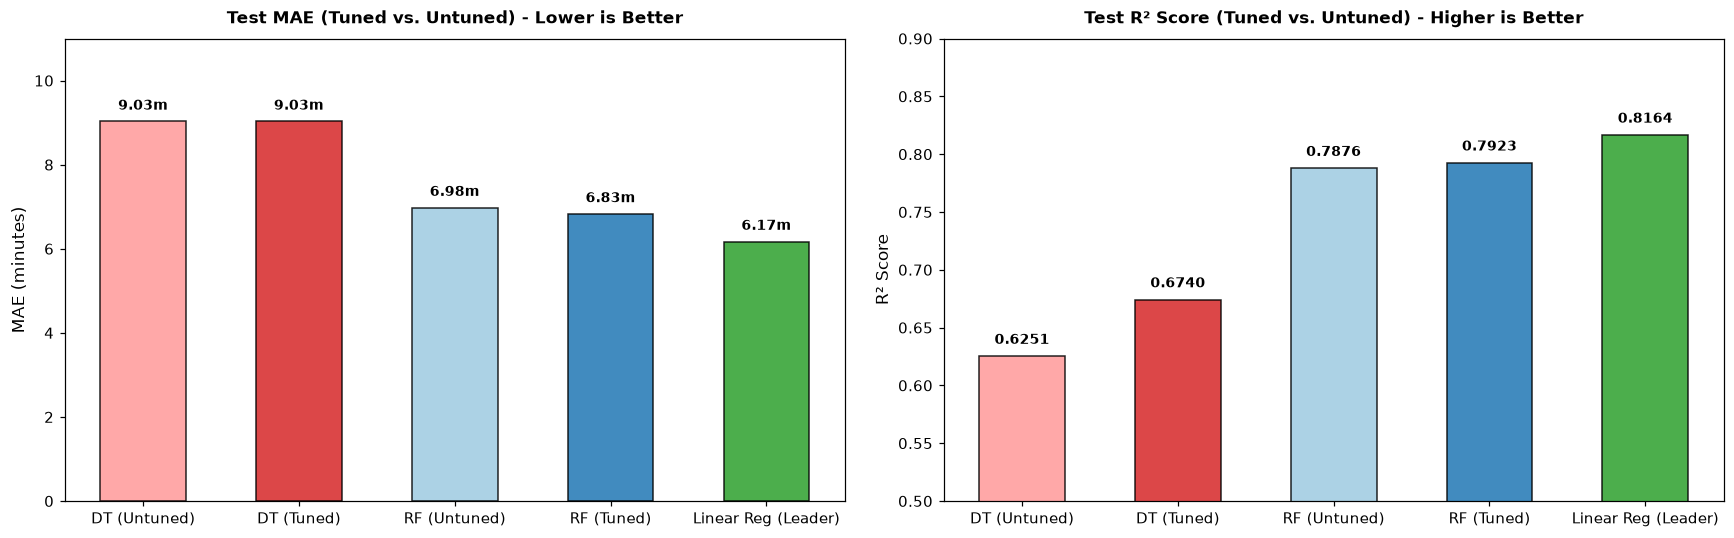

In [6]:
# Visual Diagnostics: Comparing Tuned vs Untuned Models & Benchmark
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

models_labels = ['DT (Untuned)', 'DT (Tuned)', 'RF (Untuned)', 'RF (Tuned)', 'Linear Reg (Leader)']
mae_vals = [untuned_dt_test['mae'], tuned_dt_test['mae'], untuned_rf_test['mae'], tuned_rf_test['mae'], lr_test['mae']]
r2_vals = [untuned_dt_test['r2'], tuned_dt_test['r2'], untuned_rf_test['r2'], tuned_rf_test['r2'], lr_test['r2']]
colors = ['#ff9999', '#d62728', '#9ecae1', '#1f77b4', '#2ca02c']

# 1. Test MAE Comparison
bars1 = axes[0].bar(models_labels, mae_vals, color=colors, alpha=0.85, edgecolor='black', width=0.55)
axes[0].set_title("Test MAE (Tuned vs. Untuned) - Lower is Better", fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel("MAE (minutes)", fontsize=11)
axes[0].set_ylim(0, 11)
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f"{yval:.2f}m", ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Test R² Comparison
bars2 = axes[1].bar(models_labels, r2_vals, color=colors, alpha=0.85, edgecolor='black', width=0.55)
axes[1].set_title("Test R² Score (Tuned vs. Untuned) - Higher is Better", fontsize=11, fontweight='bold', pad=10)
axes[1].set_ylabel("R² Score", fontsize=11)
axes[1].set_ylim(0.5, 0.9)
for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.008, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Analysis & Observations: Visual Progression
* **MAE Progression (Left Panel)**: Decision Tree pruning brings error down significantly, while Random Forest tuning achieves a measurable step toward the $6.83$ min mark. However, Linear Regression (green bar at $6.17$m) comfortably maintains the lowest error profile.
* **$R^2$ Variance Explained (Right Panel)**: Tuned Random Forest edges up to $0.7923$, but Linear Regression remains the sole model surpassing the $0.81$ ($81\%$) explanatory benchmark.

## 2. Executive Summary & Phase 12 Governance

### Comprehensive Q&A

1. **Which models were tuned and what were the best parameters?**
   * **Random Forest Regressor**: `max_depth=10`, `min_samples_leaf=4`, `min_samples_split=2`, `n_estimators=100` (Best CV MAE = $7.6839$ min).
   * **Decision Tree Regressor**: `max_depth=5`, `min_samples_leaf=4`, `min_samples_split=2` (Best CV MAE = $9.0285$ min).

2. **Did hyperparameter tuning improve model performance?**
   * **Yes**: Both tree models improved over their default configurations on CV and holdout test metrics.
   * Random Forest Test MAE dropped from $6.98$m $\to$ $6.83$m, and test $R^2$ rose from $0.7876$ $\to$ $0.7923$.

3. **What is the definitive best performing model?**
   * **Linear Regression** remains the unambiguous champion across all evaluation criteria on both Cross-Validation ($6.79$m MAE, $0.7512$ $R^2$) and the holdout test set ($6.17$m MAE, $0.8164$ $R^2$).

### Strict Phase 12 Boundary Confirmation
* [x] **No Test Leakage**: The holdout test set was strictly quarantined and used solely for post-tuning evaluation.
* [x] **Small Search Space**: Parameter grids were constrained to sensible, interpretable depths and leaf thresholds.
* [x] **Original Dataset Untouched**: Raw data files remain completely unedited.